In [465]:
import pandas as pd
import numpy as np
import os
from functools import reduce
import matplotlib.pyplot as plt

# Detect environment automatically
if "COLAB_GPU" in os.environ:
    #from google.colab import drive
    #drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/agri_ai_project"
else:
    BASE_DIR = os.getcwd()

PROJECT STRUCTURE (STANDARD)

In [466]:
import pandas as pd

# load existing final dataset
final_df = pd.read_csv("data/final/agri_combined_dataset.csv")

# load rainfall dataset
rain_df = pd.read_csv("data/processed/rainfall_processed.csv")

In [467]:
# Use current project folder (local machine)
BASE_DIR = os.getcwd()

RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
FINAL_DIR = os.path.join(BASE_DIR, "data", "final")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")


# Safety check (does NOT recreate, only verifies)
for path in [RAW_DIR, PROCESSED_DIR, FINAL_DIR, OUTPUT_DIR]:
    assert os.path.exists(path), f"Missing folder: {path}"

print("Connected to existing project structure successfully.")



Connected to existing project structure successfully.


COLUMN STANDARDIZATION

In [468]:
def standardize_columns(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
    )
    return df

LOAD ALL RAW DATASETS (GENERIC)

In [469]:
datasets = {}

for file in os.listdir(RAW_DIR):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        df = pd.read_csv(os.path.join(RAW_DIR, file))
        df = standardize_columns(df)
        datasets[name] = df
        print(f"Loaded {file} → shape {df.shape}")

Loaded crop_production.csv → shape (6817, 7)
Loaded rainfall.csv → shape (1981, 5)
Loaded soil_health.csv → shape (183, 19)


DATASET-WISE INSIGHT (BEFORE MERGING)

DATASET-WISE INSIGHT (BEFORE MERGING)

In [470]:
def dataset_insight(df, name):
    print(f"\n{name.upper()} DATASET")
    print("Shape:", df.shape)
    display(df.isnull().mean().mul(100).round(2))

for name, df in datasets.items():
    dataset_insight(df, name)


CROP_PRODUCTION DATASET
Shape: (6817, 7)


states        0.00
districts     0.00
crop          0.00
year          0.00
area          0.22
production    0.54
yield         0.00
dtype: float64


RAINFALL DATASET
Shape: (1981, 5)


states             0.0
district           0.0
districts          0.0
year               0.0
annual_rainfall    0.0
dtype: float64


SOIL_HEALTH DATASET
Shape: (183, 19)


state           0.0
district        0.0
n_high          0.0
n_medium        0.0
n_low           0.0
p_high          0.0
p_medium        0.0
p_low           0.0
k_high          0.0
k_medium        0.0
k_low           0.0
oc_high         0.0
oc_medium       0.0
oc_low          0.0
ph_alkaline     0.0
ph_acidic       0.0
ph_neutral      0.0
ec_nonsaline    0.0
ec_saline       0.0
dtype: float64

FIX SEMANTIC DUPLICATE COLUMNS

In [471]:
def resolve_semantic_duplicates(df):
    # Prefer singular names
    if "districts" in df.columns and "district" in df.columns:
        df.drop(columns=["districts"], inplace=True)
    if "states" in df.columns and "state" in df.columns:
        df.drop(columns=["states"], inplace=True)
    if "states" in df.columns:
        df.rename(columns={"states": "state"}, inplace=True)
    return df

for name in datasets:
    datasets[name] = resolve_semantic_duplicates(datasets[name])

AUTO MISSINGNESS PLOTS

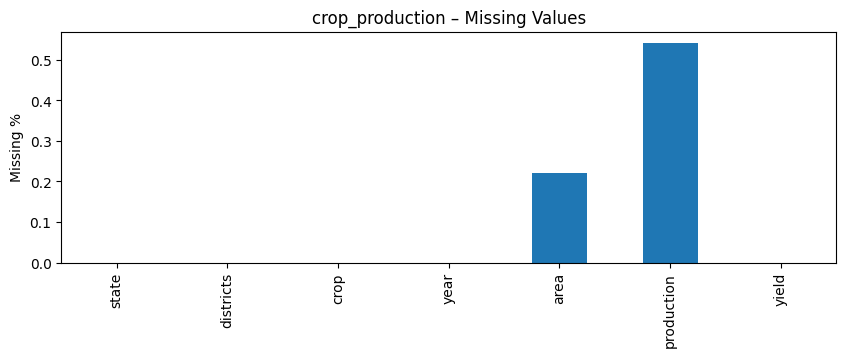

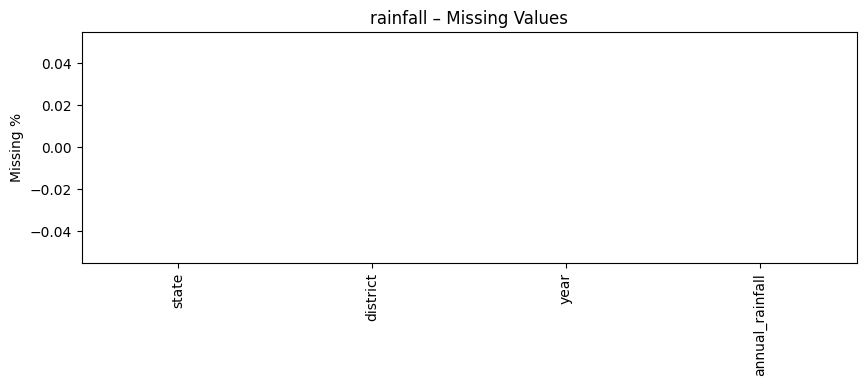

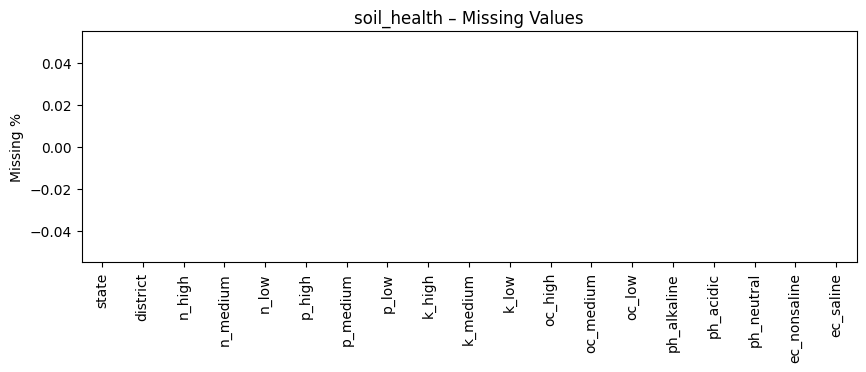

In [472]:
def plot_missing(df, title):
    df.isnull().mean().mul(100).plot(kind="bar", figsize=(10,3))
    plt.ylabel("Missing %")
    plt.title(title)
    plt.show()

for name, df in datasets.items():
    plot_missing(df, f"{name} – Missing Values")

BASIC CLEANING

In [473]:
for name in datasets:
    datasets[name] = datasets[name].drop_duplicates()

AUTO-DETECT COMMON JOIN KEYS

In [474]:
def common_columns(dfs):
    return list(set.intersection(*[set(df.columns) for df in dfs]))

JOIN_KEYS = common_columns(datasets.values())
print("Auto-detected join keys:", JOIN_KEYS)

Auto-detected join keys: ['state']


In [475]:
# Save processed individual datasets
for name, df in datasets.items():
    save_path = f"{PROCESSED_DIR}/{name}_processed.csv"
    df.to_csv(save_path, index=False)
    print(f"Saved processed dataset: {save_path}")

Saved processed dataset: c:\MCA RESEARCH\agri_ai_project\data\processed/crop_production_processed.csv
Saved processed dataset: c:\MCA RESEARCH\agri_ai_project\data\processed/rainfall_processed.csv
Saved processed dataset: c:\MCA RESEARCH\agri_ai_project\data\processed/soil_health_processed.csv


MERGE DATASETS (STATE-LEVEL)

In [476]:
rain_df = datasets["rainfall"]

rain_agg = (
    rain_df
    .groupby(["state","district", "year"], as_index=False)
    .mean(numeric_only=True)
)

print("Rainfall aggregated shape:", rain_agg.shape)



Rainfall aggregated shape: (1981, 3)


In [477]:
soil_df = datasets["soil_health"]

soil_agg = (
    soil_df
    .groupby(["state", "district"], as_index=False)
    .mean(numeric_only=True)
)

print("Soil aggregated shape:", soil_agg.shape)


Soil aggregated shape: (183, 19)


In [478]:
# ---- SIMPLE RAINFALL ADDITION ----

# get datasets
crop_df = datasets["crop_production"]
rain_df = datasets["rainfall"]
soil_df = datasets["soil_health"]

# --------------------------------------------------
# ✅ CLEAN FIRST (VERY IMPORTANT)
# --------------------------------------------------

# standardize column names
for df in [crop_df, rain_df, soil_df]:
    df.columns = df.columns.str.lower().str.strip()

# fix district mismatch
crop_df.rename(columns={"districts": "district"}, inplace=True, errors="ignore")

# clean merge keys
for df in [crop_df, rain_df, soil_df]:
    df["state"] = df["state"].astype(str).str.lower().str.strip()
    df["district"] = df["district"].astype(str).str.lower().str.strip()

# ensure year type same
crop_df["year"] = crop_df["year"].astype(int)
rain_df["year"] = rain_df["year"].astype(int)

# --------------------------------------------------
# ✅ NOW MERGE
# --------------------------------------------------

final_df = (
    crop_df
    .merge(rain_df, on=["state", "district", "year"], how="left")
    .merge(soil_df, on=["state", "district"], how="left")
)

print("✅ Merge completed")

✅ Merge completed


AUTO FEATURE TYPING

In [479]:
final_df.to_csv(
    "data/final/agri_combined_dataset.csv",
    index=False
)

print("✅ Rainfall added successfully")

✅ Rainfall added successfully


In [480]:
# detect target column again
def detect_target(df):
    keywords = ["yield", "kg_ha", "tonnes_ha", "production"]

    for col in df.columns:
        for k in keywords:
            if k in col.lower():
                print("Detected target:", col)
                return col

    # fallback
    numeric_cols = df.select_dtypes(include="number").columns
    return numeric_cols[-1]


TARGET_COLUMN = detect_target(final_df)

Detected target: production


In [481]:
def detect_feature_types(df, target_col):
    numeric = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(exclude=np.number).columns.tolist()
    if target_col in numeric:
        numeric.remove(target_col)
    return numeric, categorical

NUMERIC_FEATURES, CATEGORICAL_FEATURES = detect_feature_types(final_df, TARGET_COLUMN)

print("Target:", TARGET_COLUMN)
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)


Target: production
Numeric features: ['year', 'area', 'yield', 'n_high', 'n_medium', 'n_low', 'p_high', 'p_medium', 'p_low', 'k_high', 'k_medium', 'k_low', 'oc_high', 'oc_medium', 'oc_low', 'ph_alkaline', 'ph_acidic', 'ph_neutral', 'ec_nonsaline', 'ec_saline']
Categorical features: ['state', 'district', 'crop', 'annual_rainfall']


VERIFY YEAR AVAILABILITY

In [482]:
assert "year" in final_df.columns, "Year column missing!"
final_df["year"] = pd.to_numeric(final_df["year"], errors="coerce")


YEAR-WISE TREND ANALYSIS

In [483]:
# Create year-wise average yield trend
yearly_trend = (
    final_df
    .groupby("year")["yield"]
    .mean()
    .sort_index()
)

print("Yearly trend created")
yearly_trend.head()

Yearly trend created


year
2012    2.022127
2013    2.308627
2014    2.441368
2015    2.236451
2016    2.134878
Name: yield, dtype: float64

In [484]:
plt.figure(figsize=(8,4))
yearly_trend.plot(marker="o")
plt.title("Year-wise Average Yield Trend")
plt.ylabel("Yield")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/yearly_yield_trend.png", dpi=300)
plt.close()

print("Year-wise trend plot saved.")



Year-wise trend plot saved.


TEMPORAL COMPARISON (EARLY vs LATE YEARS)

In [485]:
mid_year = final_df["year"].median()

early = final_df[final_df["year"] <= mid_year][TARGET_COLUMN]
late  = final_df[final_df["year"] > mid_year][TARGET_COLUMN]

print("Early period mean:", early.mean())
print("Late period mean:", late.mean())


Early period mean: 84655.50070641424
Late period mean: 83982.79351157052


In [486]:
[col for col in final_df.columns if "rain" in col.lower()]

['annual_rainfall']

In [487]:
summary = pd.DataFrame({
    "period": ["early", "late"],
    "mean_yield": [early.mean(), late.mean()]
})

summary.to_csv(f"{FINAL_DIR}/early_late_summary.csv", index=False)


# WEEK 2 ANALYSIS
Using final integrated dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

final_df = pd.read_csv("data/final/agri_combined_dataset.csv")

final_df.head()

,state,district,crop,year,area,production,yield,annual_rainfall,n_high,n_medium,...,k_medium,k_low,oc_high,oc_medium,oc_low,ph_alkaline,ph_acidic,ph_neutral,ec_nonsaline,ec_saline
0,andhra pradesh,alluri sitharama raju,Cotton(lint),2022,2682.0,7614.0,2.84,NaN,3.26,54.11,...,44.99,29.87,27.25,64.48,8.27,0.12,18.93,80.95,99.81,0.19
1,andhra pradesh,anakapalli,Cotton(lint),2022,82.0,230.0,2.80,NaN,12.10,25.02,...,22.88,8.79,12.98,25.62,61.40,0.62,0.10,99.27,98.99,1.01
2,andhra pradesh,anantapur,Cotton(lint),2012,28000.0,35000.0,1.25,536,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
3,andhra pradesh,anantapur,Cotton(lint),2013,37661.0,77316.0,2.05,501.7,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
4,andhra pradesh,anantapur,Cotton(lint),2014,73734.0,103779.0,1.41,437.8,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39


## Task 1: Temporal Trend Analysis
Analyze how crop yield changes over time using year-wise averages.

In [2]:
yearly_yield = (
    final_df.groupby("year")["yield"]
    .mean()
    .reset_index()
)

yearly_yield

,year,yield
0,2012,2.022127
1,2013,2.308627
2,2014,2.441368
3,2015,2.236451
4,2016,2.134878
5,2017,2.430035
6,2018,2.153382
7,2019,2.311654
8,2020,2.412110
9,2021,2.609878


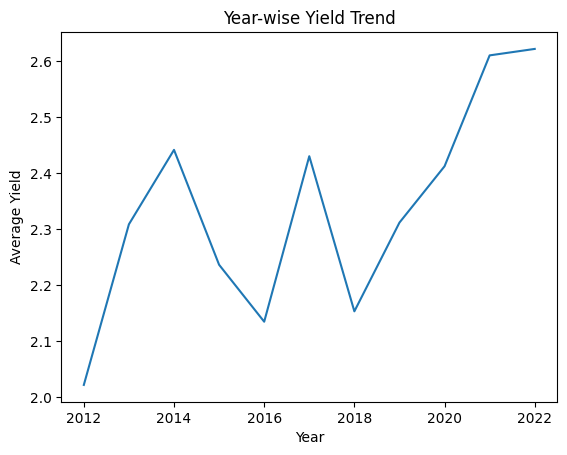

In [3]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yearly_yield["year"],
         yearly_yield["yield"])

plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.title("Year-wise Yield Trend")

plt.show()

### Interpretation

The year-wise average yield demonstrates an overall increasing trend
between 2012 and 2022, indicating gradual improvement in agricultural
productivity.

The trend shows fluctuations during the earlier period (2012–2018),
including temporary declines around 2015–2016, suggesting instability
possibly caused by climatic variability or changing agricultural
conditions.

After 2018, yield exhibits a consistent and sustained growth pattern,
with steady increases observed each year until 2022. This phase of
continuous improvement may reflect advancements in irrigation,
improved crop varieties, better farming practices, and technological
adoption in agriculture.

Thus, while early years show variability, the later period indicates
stabilization and long-term productivity growth.

## Task 2: Temporal Regime Comparison
Compare crop yield between early and late time periods using statistical testing.

In [4]:
median_year = final_df["year"].median()
median_year

np.float64(2017.0)

In [5]:
early = final_df[final_df["year"] <= median_year]["yield"]
late = final_df[final_df["year"] > median_year]["yield"]

In [6]:
early.mean(), late.mean()

(np.float64(2.260724922731104), np.float64(2.427783916513198))

In [7]:
from scipy import stats

stats.ttest_ind(
    early.dropna(),
    late.dropna(),
    equal_var=False
)

TtestResult(statistic=np.float64(-4.048483085273367), pvalue=np.float64(5.2143194324133924e-05), df=np.float64(6568.3061264658745))

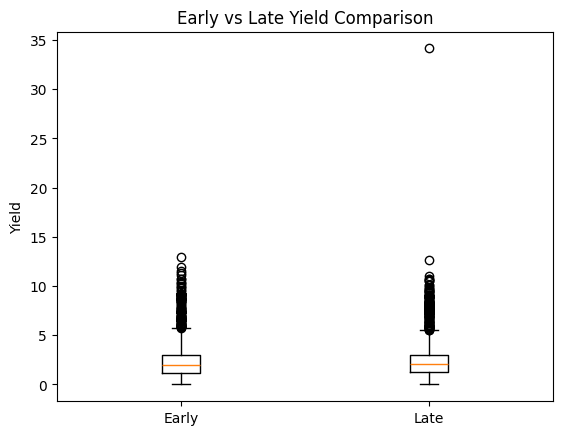

In [20]:
plt.figure()

plt.boxplot(
    [early.dropna(), late.dropna()],
    tick_labels=["Early", "Late"]
)

plt.ylabel("Yield")
plt.title("Early vs Late Yield Comparison")

plt.show()

### Interpretation

The boxplot compares the distribution of crop yield between the early
and late time periods defined using the median year.

The late period shows a higher median yield compared to the early
period, indicating improvement in agricultural productivity over time.
The spread of values also suggests continued variability, but the
overall distribution has shifted upward in the later years.

Combined with the statistical t-test results (p-value < 0.05), the
increase in yield is statistically significant and unlikely to be due
to random variation.

This improvement may be attributed to advancements in agricultural
technology, expansion of irrigation facilities, improved seed
varieties, better nutrient management, and supportive agricultural
policies that enhanced farming efficiency in recent years.

## Task 3: State-wise Variability Analysis
Analyze yield variation across different states using mean and standard deviation.

In [9]:
state_stats = (
    final_df.groupby("state")["yield"]
    .agg(
        mean_yield="mean",
        variance_yield="var",
        std_dev_yield="std"
    )
    .reset_index()
)

state_stats

,state,mean_yield,variance_yield,std_dev_yield
0,andhra pradesh,2.568227,1.908275,1.381403
1,karnataka,2.175483,1.438312,1.199296
2,madhya pradesh,1.885317,1.212306,1.101048
3,maharashtra,1.568433,1.700798,1.304147
4,tamil nadu,3.611175,5.384386,2.320428


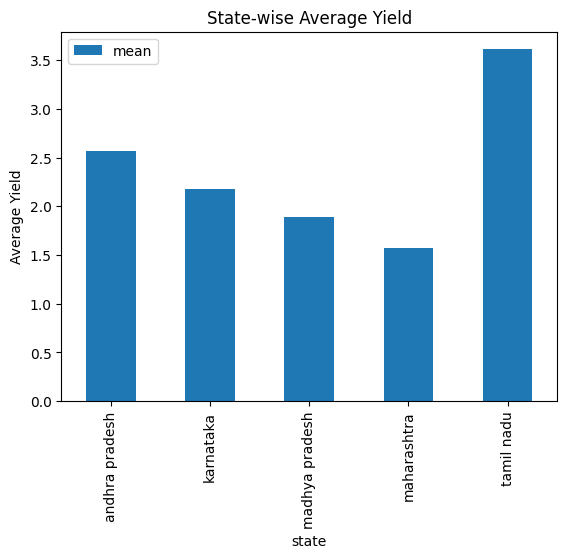

In [10]:
import matplotlib.pyplot as plt

state_stats.plot(
    x="state",
    y="mean",
    kind="bar"
)

plt.xticks(rotation=90)
plt.ylabel("Average Yield")
plt.title("State-wise Average Yield")

plt.show()

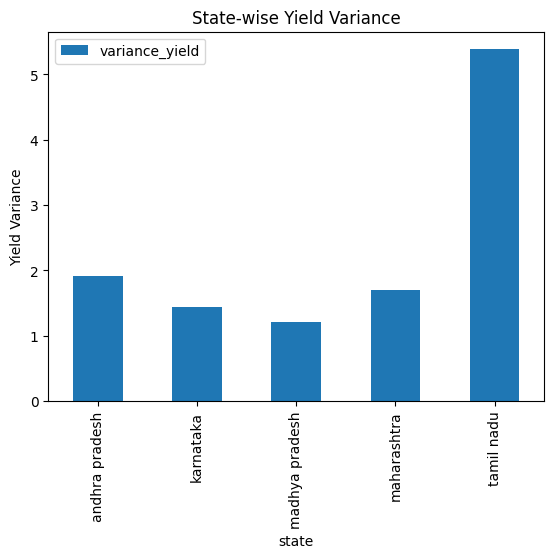

In [22]:
state_stats.plot(
    x="state",
    y="variance_yield",
    kind="bar"
)

plt.xticks(rotation=90)
plt.ylabel("Yield Variance")
plt.title("State-wise Yield Variance")

plt.show()



### Interpretation

States with higher mean yield demonstrate better agricultural
productivity. However, higher standard deviation indicates unstable
yield performance across years.

Stable states show consistent production with lower variability,
while volatile states may depend more heavily on rainfall or climate
conditions, leading to fluctuating outcomes.

Importantly, higher average yield does not necessarily imply lower
variability. Some high-yield states also exhibit large fluctuations,
suggesting that productivity and stability are influenced by different
factors such as irrigation access, soil conditions, and climatic risk.

## Task 4: Rainfall–Yield Relationship
Analyze correlation between annual rainfall and crop yield.

In [11]:
final_df["annual_rainfall"] = pd.to_numeric(
    final_df["annual_rainfall"],
    errors="coerce"
)

In [12]:
final_df[["yield", "annual_rainfall"]].corr()

,yield,annual_rainfall
yield,1.000000,-0.002213
annual_rainfall,-0.002213,1.000000


In [13]:
early_df = final_df[final_df["year"] <= median_year]
late_df = final_df[final_df["year"] > median_year]

early_df[["yield","annual_rainfall"]].corr()

,yield,annual_rainfall
yield,1.000000,-0.000884
annual_rainfall,-0.000884,1.000000


In [14]:
late_df[["yield","annual_rainfall"]].corr()

,yield,annual_rainfall
yield,1.000000,-0.018137
annual_rainfall,-0.018137,1.000000



### Rainfall–Yield Correlation Interpretation

The correlation between annual rainfall and crop yield is approximately
zero (-0.002), indicating a very weak relationship between rainfall
and agricultural productivity.

This suggests that rainfall alone does not strongly determine yield
outcomes. Other factors such as irrigation availability, soil quality,
fertilizer use, crop varieties, and farming practices play a more
significant role in influencing productivity.

## Task 5: Yield Stability & Uncertainty Analysis
Measure yield variability across crops to identify stability patterns.

In [16]:
crop_stability = (
    final_df.groupby("crop")["yield"]
    .std()
    .reset_index(name="yield_std")
)

crop_stability

,crop,yield_std
0,Cotton(lint),1.549762
1,Groundnut,0.852489
2,Maize,2.283030
3,Ragi,0.984380
4,Rice,1.206725


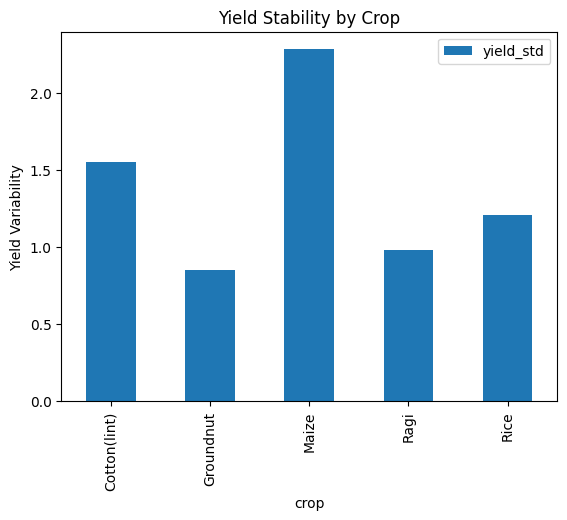

In [17]:
import matplotlib.pyplot as plt

crop_stability.plot(
    x="crop",
    y="yield_std",
    kind="bar"
)

plt.ylabel("Yield Variability")
plt.title("Yield Stability by Crop")

plt.show()

### Crop Sensitivity to Variability

Yield variability analysis shows that crops differ significantly
in their stability across years. Maize exhibits the highest standard
deviation, indicating strong sensitivity to environmental and climatic
conditions. Cotton also shows relatively high variability, suggesting
greater production uncertainty.

In contrast, crops such as Groundnut and Ragi demonstrate lower
variability, indicating more stable and consistent production patterns
over time.

## Task 6: Soil Context Interpretation
Interpret soil indicators as contextual agricultural features.

In [19]:
final_df.describe()

,year,area,production,yield,annual_rainfall,n_high,n_medium,n_low,p_high,p_medium,...,k_medium,k_low,oc_high,oc_medium,oc_low,ph_alkaline,ph_acidic,ph_neutral,ec_nonsaline,ec_saline
count,6817.000000,6.802000e+03,6.780000e+03,6817.000000,6065.000000,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000,...,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000,6731.000000
mean,2017.127035,3.683967e+04,8.433393e+04,2.340566,1105.840824,1.390116,19.529911,79.079935,34.216062,51.141163,...,45.688898,8.524126,17.712942,28.927535,53.359758,3.019679,3.598565,93.381443,95.897730,4.102270
std,3.211765,9.362518e+04,2.165717e+05,1.695830,664.334828,6.640608,22.811173,24.681794,27.239572,25.702140,...,26.798320,13.344930,20.651301,19.238095,29.421607,5.144169,8.503935,9.418462,11.963536,11.963536
min,2012.000000,2.500000e-01,0.000000e+00,0.000000,277.700000,0.000000,0.000000,0.790000,0.040000,0.190000,...,0.000000,0.010000,0.000000,0.030000,0.200000,0.000000,0.000000,26.300000,0.000000,0.000000
25%,2014.000000,5.402500e+02,8.320000e+02,1.210000,744.200000,0.010000,1.320000,67.920000,10.230000,28.870000,...,23.750000,0.810000,1.510000,13.190000,27.900000,0.170000,0.060000,91.550000,97.700000,0.110000
50%,2017.000000,5.346000e+03,9.925500e+03,2.000000,953.200000,0.040000,10.670000,89.290000,28.250000,52.110000,...,43.420000,3.000000,10.640000,30.000000,54.060000,0.790000,0.370000,96.630000,99.260000,0.740000
75%,2020.000000,3.507325e+04,7.623500e+04,3.000000,1243.500000,0.240000,30.020000,98.590000,53.430000,75.060000,...,67.090000,9.880000,25.950000,39.810000,79.720000,3.340000,3.150000,99.220000,99.890000,2.300000
max,2022.000000,2.260000e+06,5.400540e+06,34.140000,5454.900000,60.300000,96.440000,100.000000,99.710000,97.990000,...,99.830000,80.400000,96.070000,96.290000,99.940000,31.830000,73.700000,100.000000,100.000000,100.000000


### Interpretation
 Why Soil Data is Treated as Static

Soil characteristics are considered static because they change very
slowly over time compared to variables such as rainfall or crop yield,
which vary annually. Properties like soil nutrient composition and pH
levels represent long-term environmental conditions rather than short-
term fluctuations.

Since the dataset analyzes temporal yield patterns across years,
soil indicators provide a stable baseline describing agricultural
capacity of a region rather than a time-varying influence.

### Soil Context and State-Level Yield Differences

Soil indicators help explain differences in agricultural productivity
across states. Regions with balanced soil pH and higher nutrient
availability provide more favorable growing conditions, leading to
consistently higher yields.

Conversely, states with less optimal soil conditions may experience
lower productivity even when rainfall levels are adequate. Therefore,
soil data provides important environmental context for interpreting
state-wise yield variation rather than acting as a direct predictor of
year-to-year changes.